In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import seaborn as sns

In [2]:
plt.style.use("~/nice.mplstyle")

In [3]:
metric = "rmse"

In [4]:
nice_names = lambda name : name.replace("_", " ").capitalize()

In [5]:
def single_plot(ax, dsdict, varname, sel=None, **kwargs):
    xticks = None
    for label, xds in dsdict.items():
        
        plotme = xds[varname] if sel is None else xds[varname].sel(**sel)
        if xticks is None:
            xticks = plotme.fhr.values
        df = plotme.to_dataframe()#.reset_index()
        if label == "HRRR":
            color="gray"
        elif label == "THRRR":
            color="black"
        else:
            color=None
        sns.lineplot(
            data=df,
            x="fhr",
            y=varname,
            ax=ax,
            label=label,
            color=color,
            **kwargs,
        )
    xticks = xticks if len(xticks)<10 else np.concatenate([ [xticks[0]], xticks[4::4]])
    ax.set(
        ylabel=metric.upper() if ax.get_subplotspec().is_first_col() else "",
        xlabel="Forecast Hour" if ax.get_subplotspec().is_last_row() else "",
        title=nice_names(varname) if ax.get_subplotspec().is_first_row() else "",
        xticks=xticks,
    )
    ax.legend(frameon=False)

In [6]:
def plot_surface_error(surface_vars, dsdict, model_filter=None, **kwargs):
    ncols = len(surface_vars)
    fig, axs = plt.subplots(1, ncols, figsize=(5*ncols, 4), constrained_layout=True)

    if len(surface_vars) == 1:
        axs = [axs]
    for varname, ax in zip(surface_vars, axs):
        single_plot(ax=ax, dsdict=dsdict, varname=varname, **kwargs)
    return fig, axs

In [7]:
def plot_level_vars(level_vars, dsdict, **kwargs):
    
    levels = dsdict["HRRR"].level.values
    ncols = len(level_vars)
    nrows = len(levels)
    fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.5*nrows), constrained_layout=True)

    if len(levels) == 1:
        axs = [axs]
    if len(level_vars) == 1:
        axs = [axs]

    sel = kwargs.pop("sel", {})
    for level, axr in zip(levels, axs):
        for varname, ax in zip(level_vars, axr):
            
            sel["level"] = level
            single_plot(ax=ax, dsdict=dsdict, varname=varname, sel=sel, **kwargs)
            ax.legend(title=f"{level} hPa", frameon=False)
    return fig, axs

In [8]:
surface_fields = ["surface_pressure", "10m_zonal_wind", "10m_meridional_wind", "2m_temperature", "2m_specific_humidity"]
pressure_fields = ["geopotential_height", "zonal_wind", "meridional_wind", "temperature", "specific_humidity"]

In [14]:
metric="rmse"
latent = {
    "qc = 0": xr.open_dataset(f"/pscratch/sd/t/timothys/nested-eagle/1.00deg-15km/mse06h/experiments/latent-updates/heal5/inference-validation/obs-metrics-qc0/{metric}.convobs.nested-lam.nc", decode_timedelta=False),
    "qc = 1": xr.open_dataset(f"/pscratch/sd/t/timothys/nested-eagle/1.00deg-15km/mse06h/experiments/latent-updates/heal5/inference-validation/obs-metrics-qc1/{metric}.convobs.nested-lam.nc", decode_timedelta=False),
    "qc = 2": xr.open_dataset(f"/pscratch/sd/t/timothys/nested-eagle/1.00deg-15km/mse06h/experiments/latent-updates/heal5/inference-validation/obs-metrics/{metric}.convobs.nested-lam.nc", decode_timedelta=False),
}
    
latent["HRRR"] = xr.open_dataset(f"/pscratch/sd/t/timothys/nested-eagle/1.00deg-15km/baselines/hrrr-forecasts-vs-hrrr-analysis/trim10/obs-metrics/{metric}.convobs.lam.nc", decode_timedelta=True)

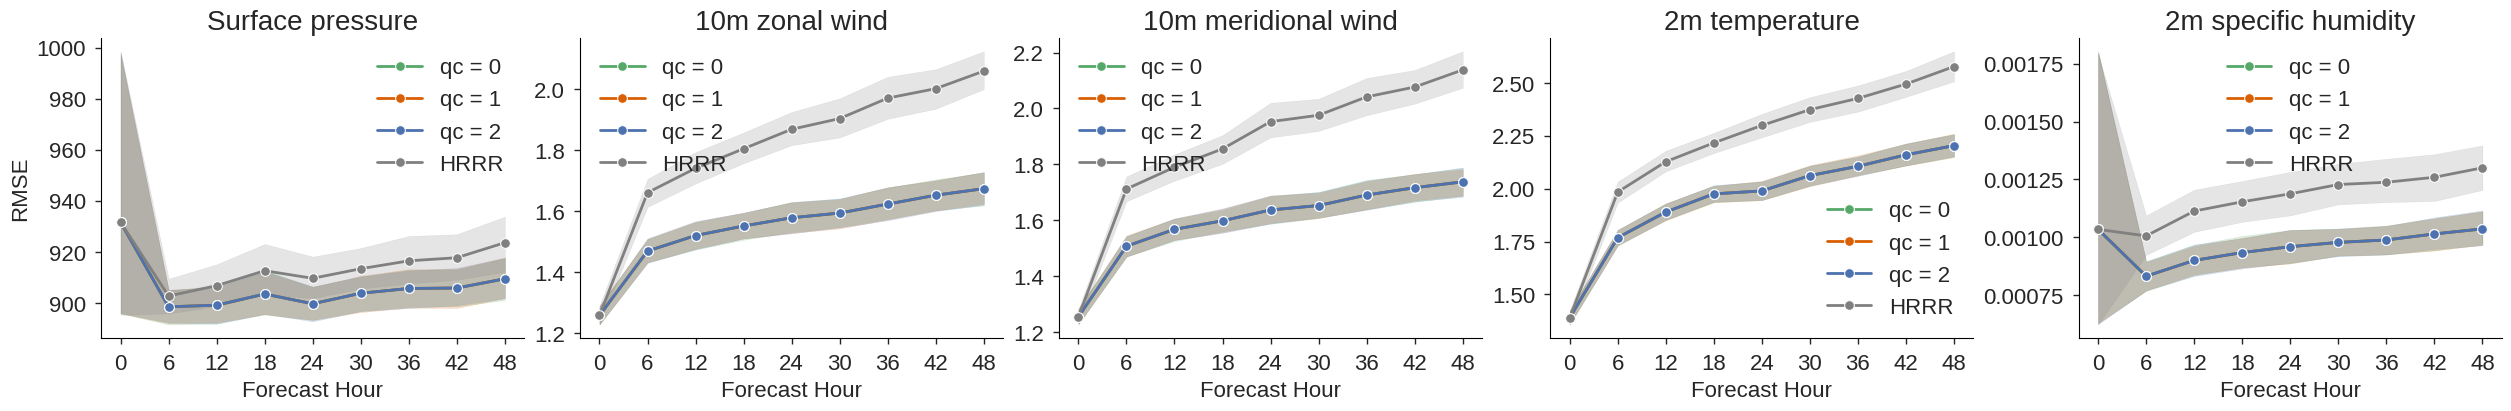

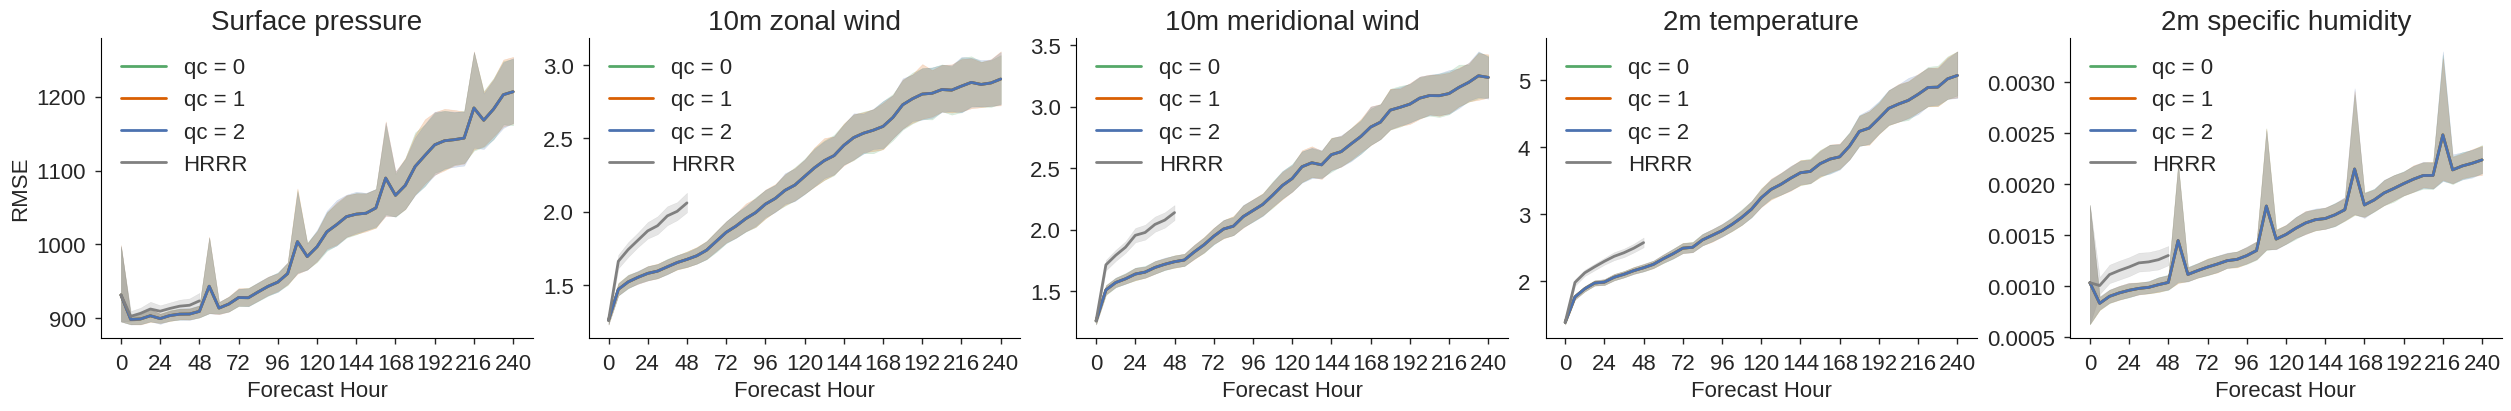

In [15]:
for name, kwargs in zip(["48h", "10d"], [{"sel": {"fhr": slice(49)}, "marker": "o"}, {}]):
    fig, axs = plot_surface_error(
        surface_fields,
        #["surface_pressure", "2m_temperature", "2m_specific_humidity"],
        dsdict=latent,
        estimator="mean",
        #errorbar=lambda df: (df.groupby('fhr').min(), df.groupby('fhr').max()),
        **kwargs,
    )

In [16]:
sprmse = latent["qc = 0"]["surface_pressure"]

(array([ 1.,  1.,  4., 19., 31., 36., 21.,  2.,  0.,  1.]),
 array([ 767.34535044,  793.66460374,  819.98385703,  846.30311032,
         872.62236362,  898.94161691,  925.2608702 ,  951.5801235 ,
         977.89937679, 1004.21863008, 1030.53788338]),
 <BarContainer object of 10 artists>)

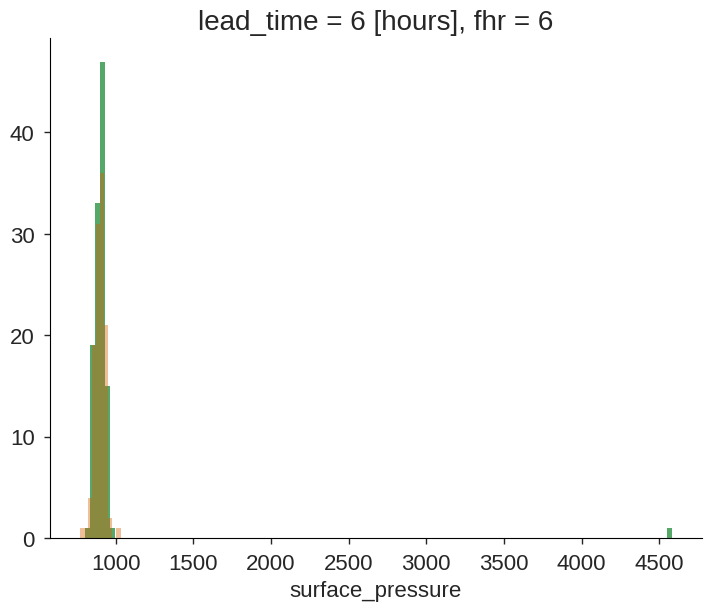

In [17]:
sprmse.sel(fhr=0).plot.hist(bins=120)
sprmse.sel(fhr=6).plot.hist(bins=10,alpha=.4)

There are huge outliers in surface pressure, or even just one, at analysis time. This throws off the mean estimate big time. Making the QC flag more restrictive does nothing to solve the problem

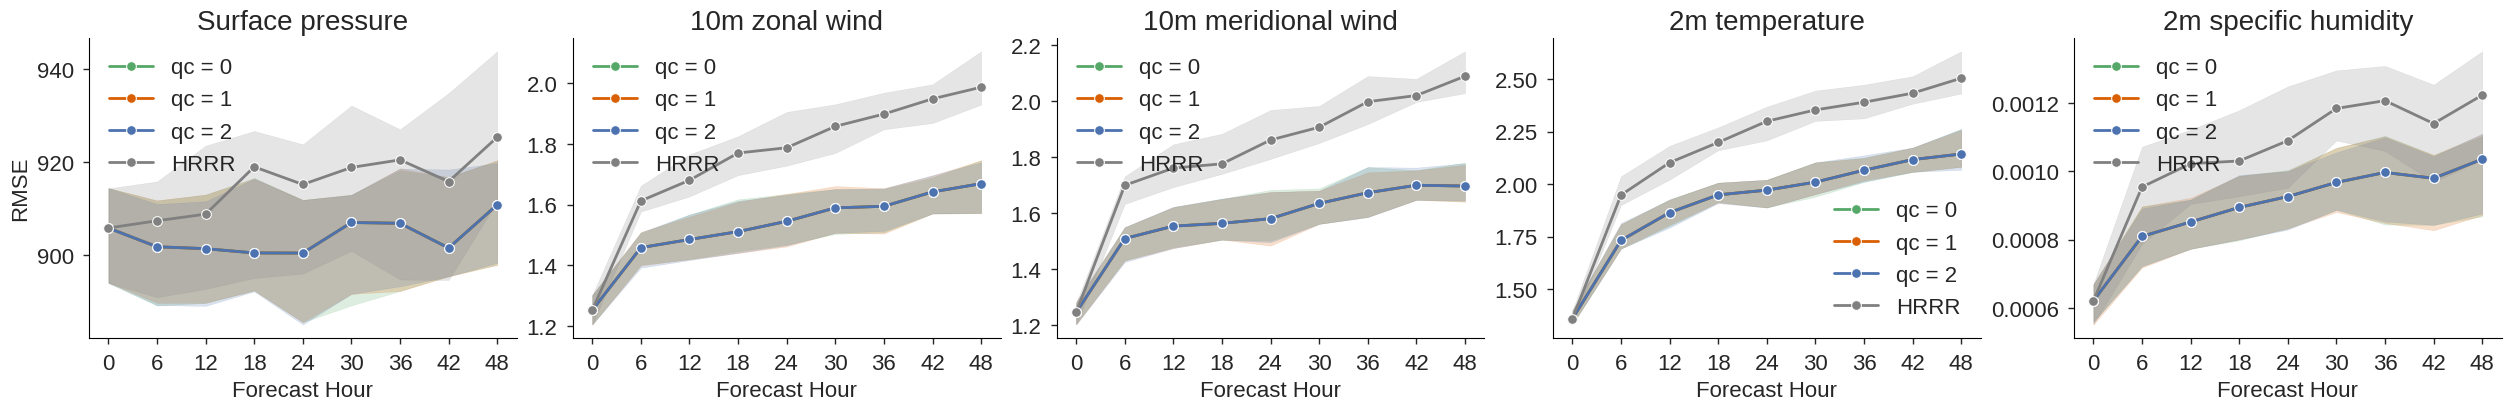

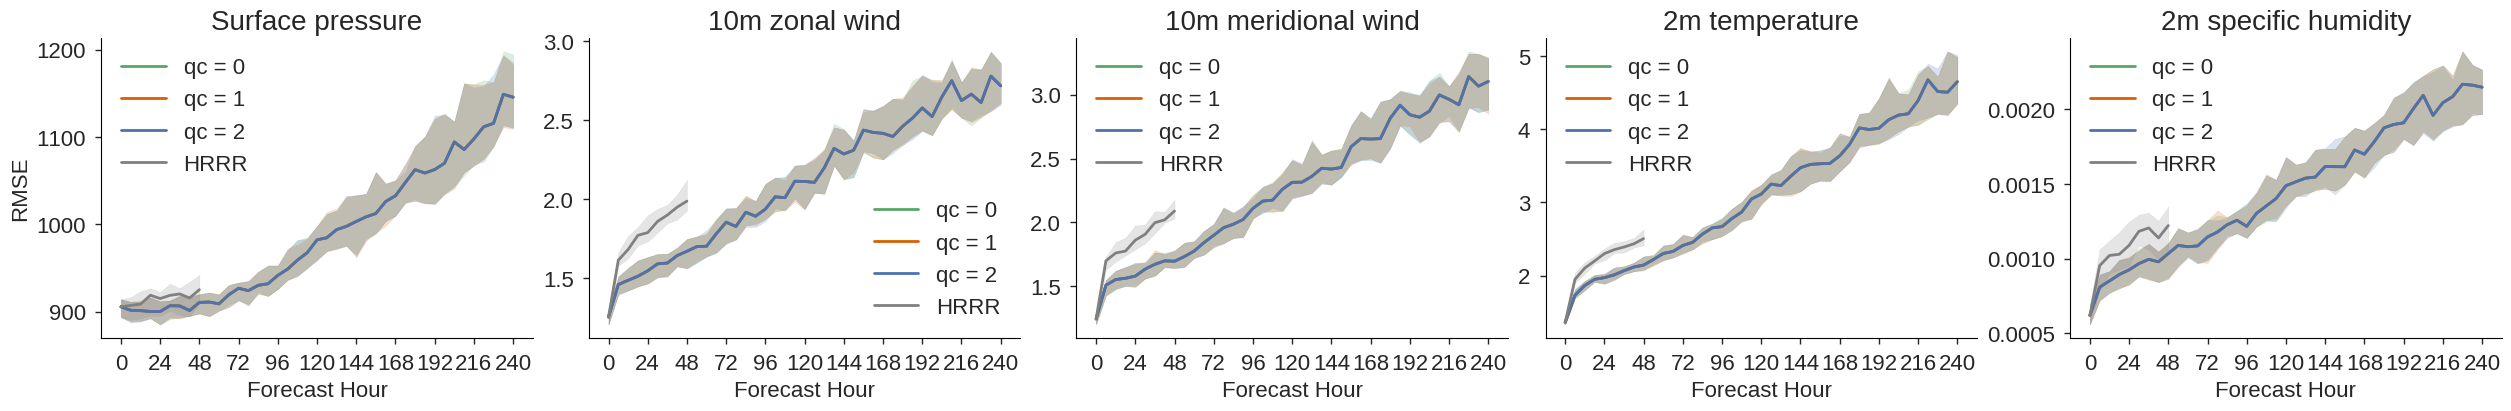

In [18]:
for name, kwargs in zip(["48h", "10d"], [{"sel": {"fhr": slice(49)}, "marker": "o"}, {}]):
    fig, axs = plot_surface_error(
        surface_fields,
        #["surface_pressure", "2m_temperature", "2m_specific_humidity"],
        dsdict=latent,
        estimator="median",
        **kwargs,
    )

Comparing the median appears to be more robust.

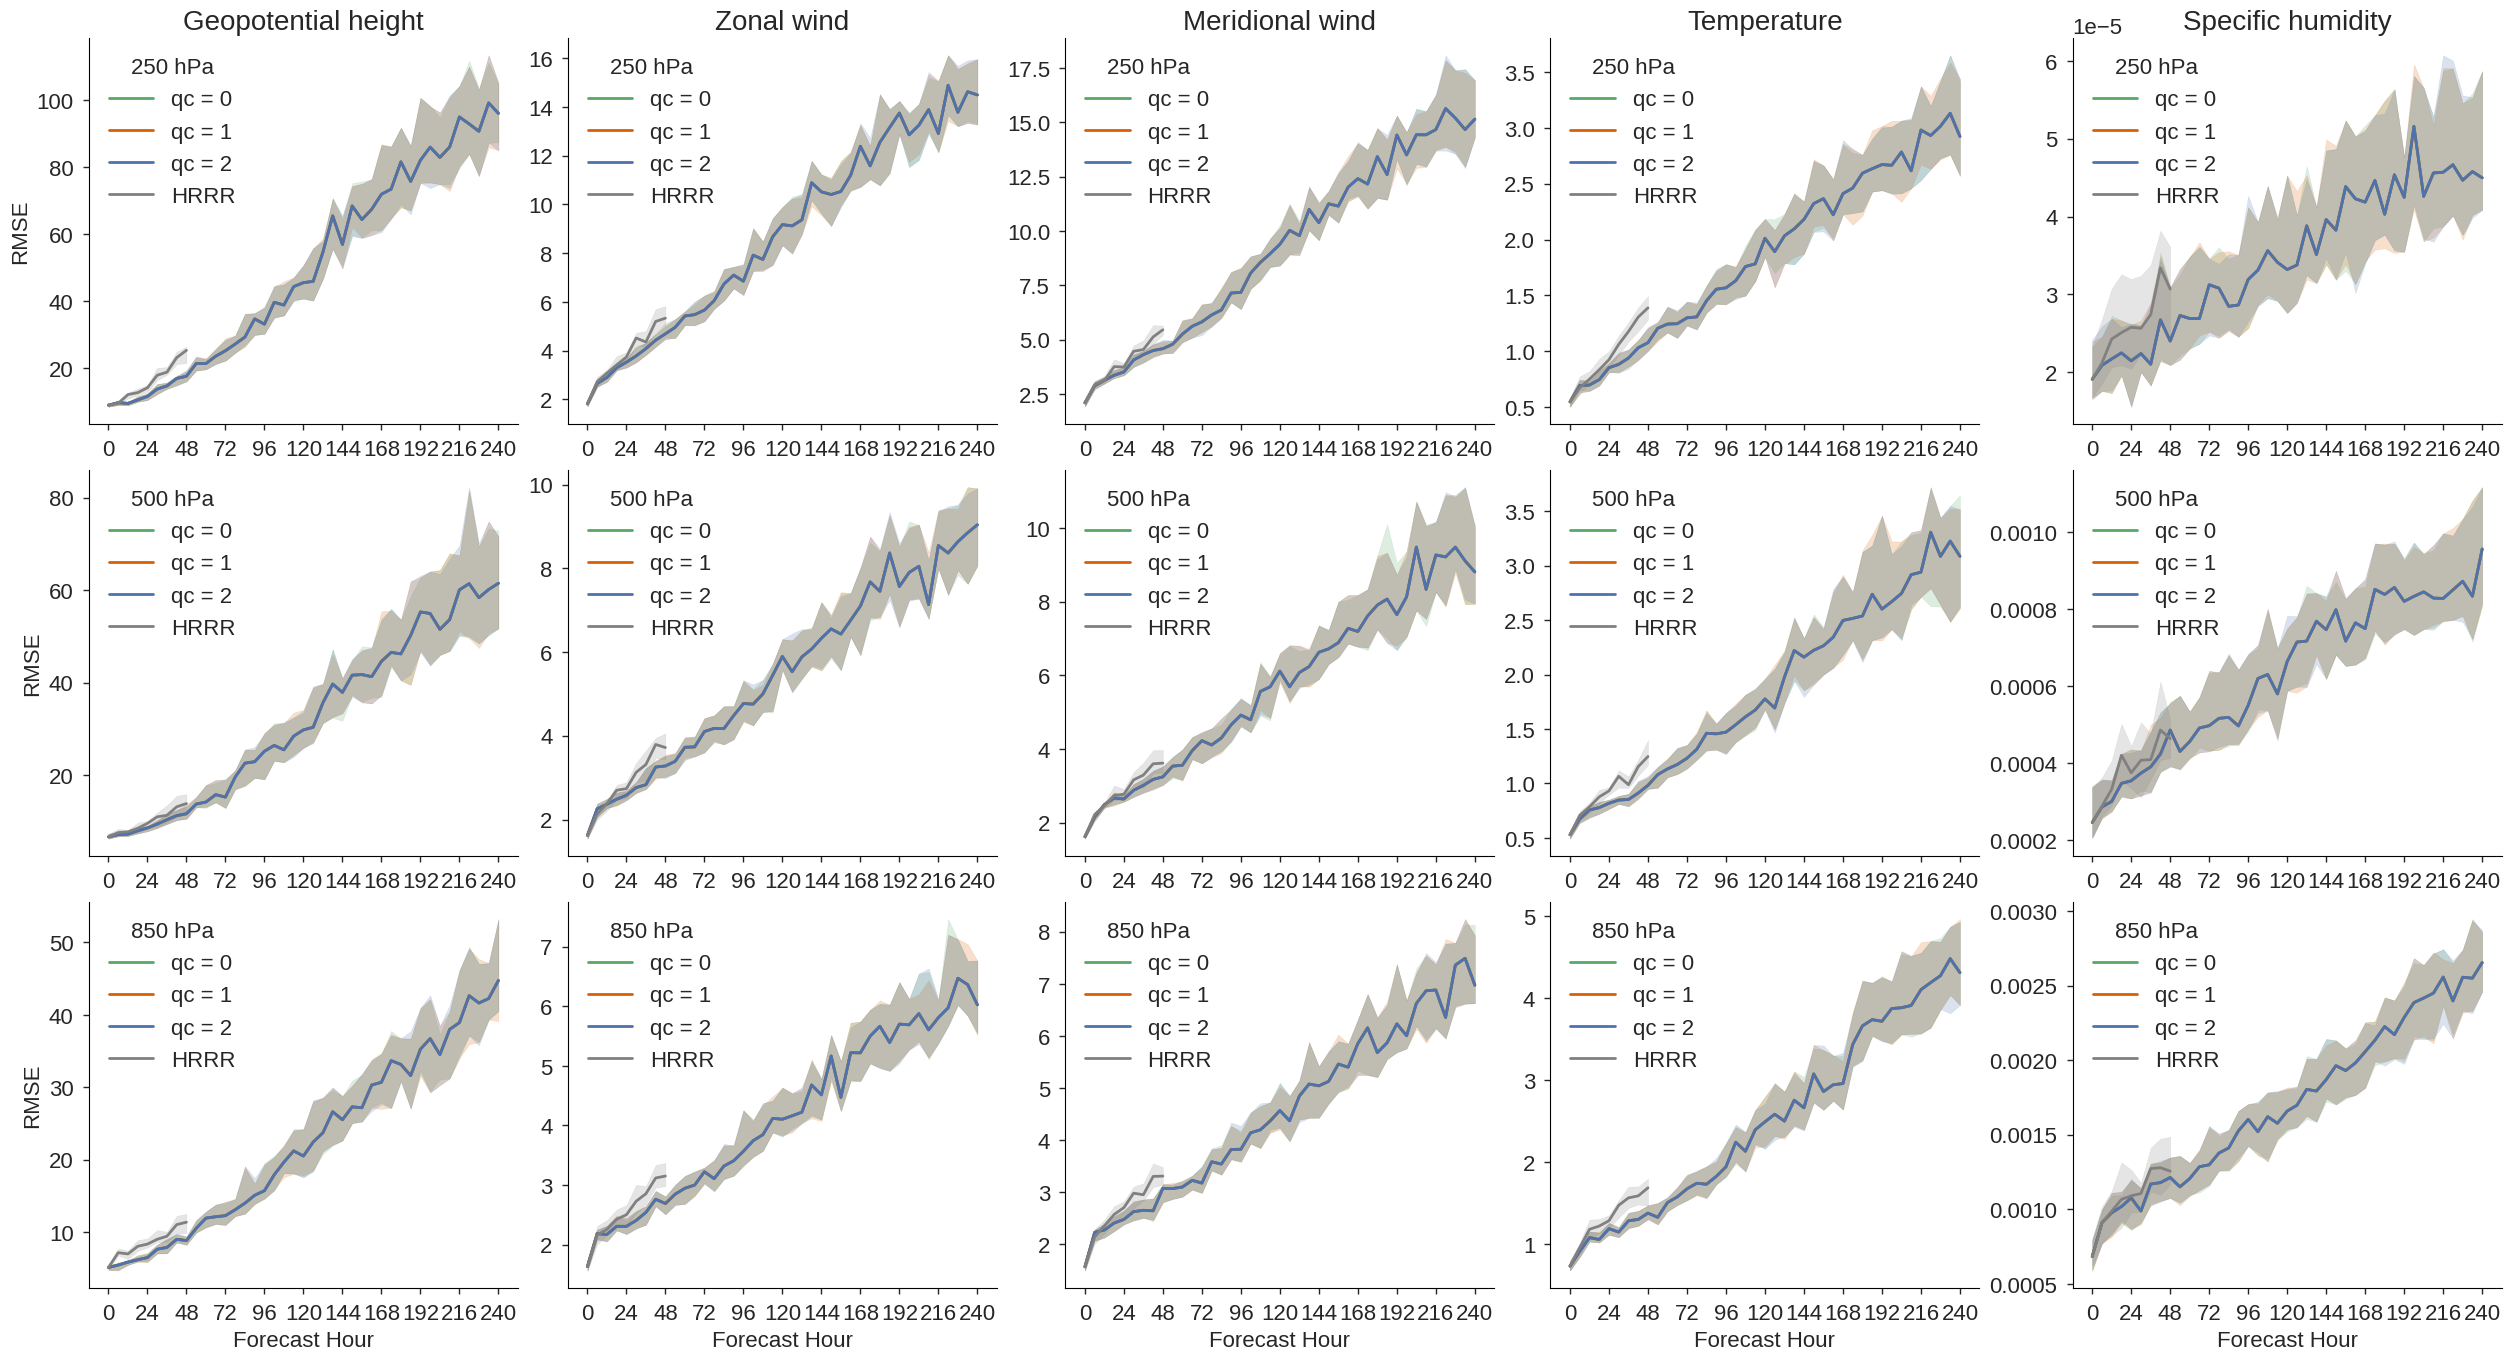

In [19]:
fig, axs = plot_level_vars(
    pressure_fields,
    dsdict=latent,
    estimator="median",
)

And this eliminates the blips that appeared in the pressure level fields too.